<a href="https://colab.research.google.com/github/yakoubbenabbas/Machine-Learning-supervised-learning-/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing libraries needed for this project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score ,precision_score , recall_score , f1_score , classification_report
from sklearn.model_selection import cross_val_score


PHASE 1: Data Processing

For this project i am going to be using kaggle's Credit Card Fraud detection Data set.

The objective for this project is that companies will be able to recognise fraud activity using the machine learning model.

This dataset contains credit card transactions made by European cardholders in the year 2023. It comprises over 550,000 records, and the data has been anonymized to protect the cardholders' identities. The primary objective of this dataset is to facilitate the development of fraud detection algorithms and models to identify potentially fraudulent transactions.

Now let's begin coding phase 1.

In [ ]:
#reading the csv file
data = pd.read_csv("/content/creditcard_2023.csv.zip")
data

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,568625,-0.833437,0.061886,-0.899794,0.904227,-1.002401,0.481454,-0.370393,0.189694,-0.938153,...,0.167503,0.419731,1.288249,-0.900861,0.560661,-0.006018,3.308968,0.081564,4394.16,1
568626,568626,-0.670459,-0.202896,-0.068129,-0.267328,-0.133660,0.237148,-0.016935,-0.147733,0.483894,...,0.031874,0.388161,-0.154257,-0.846452,-0.153443,1.961398,-1.528642,1.704306,4653.40,1
568627,568627,-0.311997,-0.004095,0.137526,-0.035893,-0.042291,0.121098,-0.070958,-0.019997,-0.122048,...,0.140788,0.536523,-0.211100,-0.448909,0.540073,-0.755836,-0.487540,-0.268741,23572.85,1
568628,568628,0.636871,-0.516970,-0.300889,-0.144480,0.131042,-0.294148,0.580568,-0.207723,0.893527,...,-0.060381,-0.195609,-0.175488,-0.554643,-0.099669,-1.434931,-0.159269,-0.076251,10160.83,1


In [ ]:
#displaying general information about the data set like data type of each feature
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [ ]:
#checking for missing values
data.isnull().sum()

,0
id,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
#checking stats for numerical columns or features
data.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.638058e-17,-1.319545e-16,-3.518788e-17,-2.879008e-17,7.997245e-18,-3.958636e-17,-3.198898e-17,2.109273e-17,3.998623e-17,...,4.758361e-17,3.948640e-18,6.194741e-18,-2.799036e-18,-3.178905e-17,-7.497417e-18,-3.598760e-17,2.609101e-17,12041.957635,0.5
std,164149.486121,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222e+00,-9.952786e+00,-2.111111e+01,-4.351839e+00,-1.075634e+01,-3.751919e+00,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969e+00,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-6.560203e-01,-2.934955e-01,-4.458712e-01,-2.835329e-01,-1.922572e-01,-5.687446e-01,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-6.318948e-01,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-7.376152e-02,8.108788e-02,7.871758e-02,2.333659e-01,-1.145242e-01,9.252647e-02,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-1.189208e-02,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,7.070047e-01,4.397368e-01,4.977881e-01,5.259548e-01,4.729905e-02,5.592621e-01,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,6.728879e-01,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536e+00,4.271689e+01,2.616840e+01,2.178730e+02,5.958040e+00,2.027006e+01,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285e+00,1.132311e+02,7.725594e+01,24039.930000,1.0


In [ ]:
#checking for duplicates
data.duplicated().sum()

np.int64(0)

In [ ]:
#dropping id column as it is not needed and to prevent overfiting
data.drop(columns=["id"],inplace=True)

In [ ]:
data.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class'],
      dtype='object')

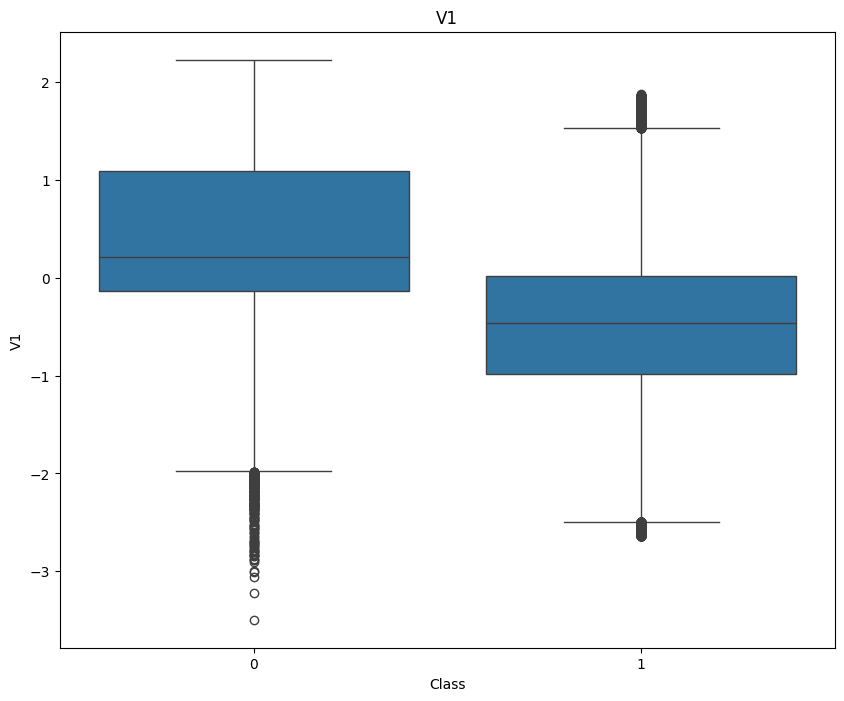

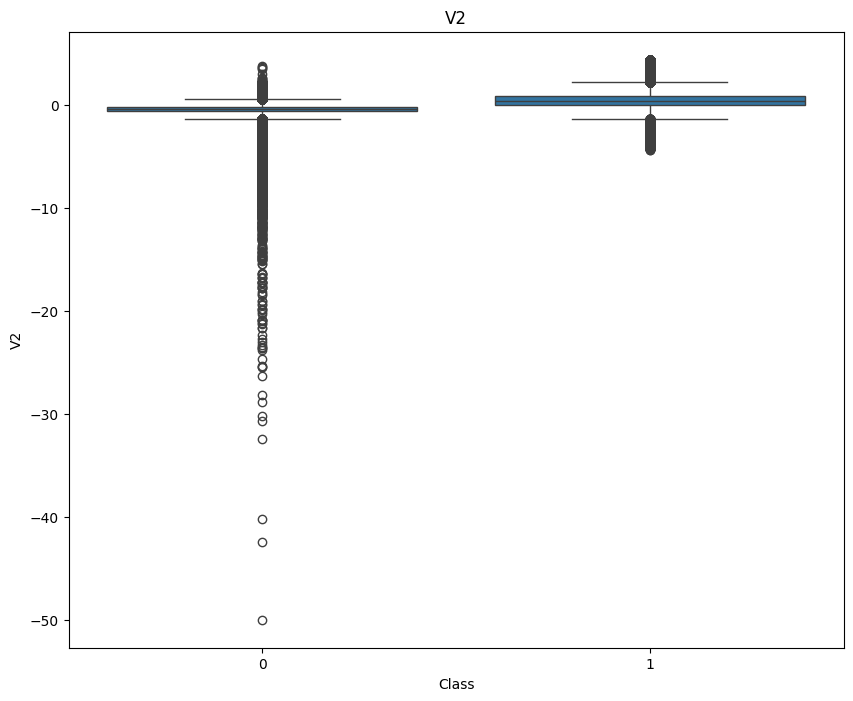

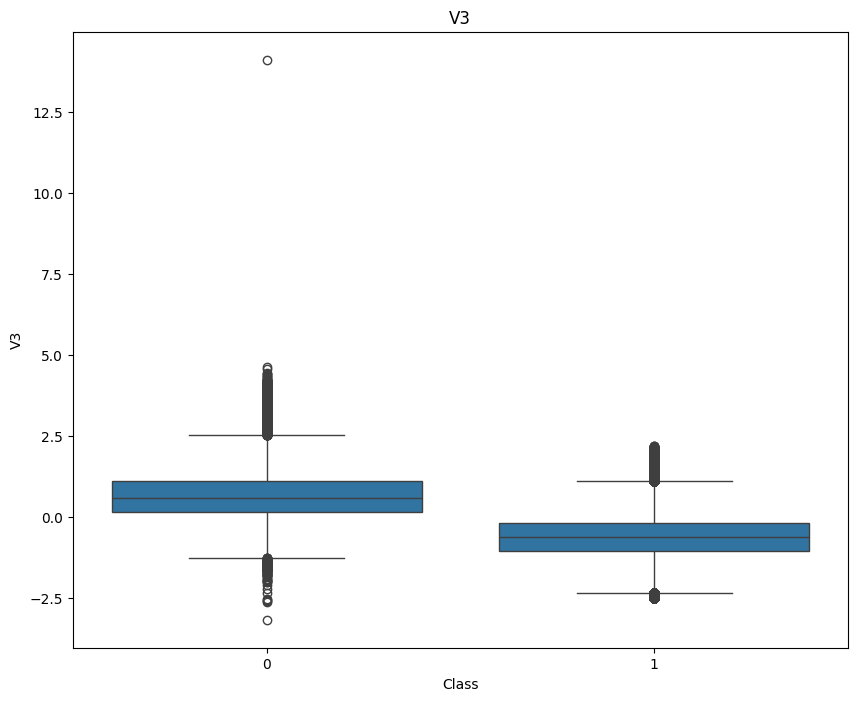

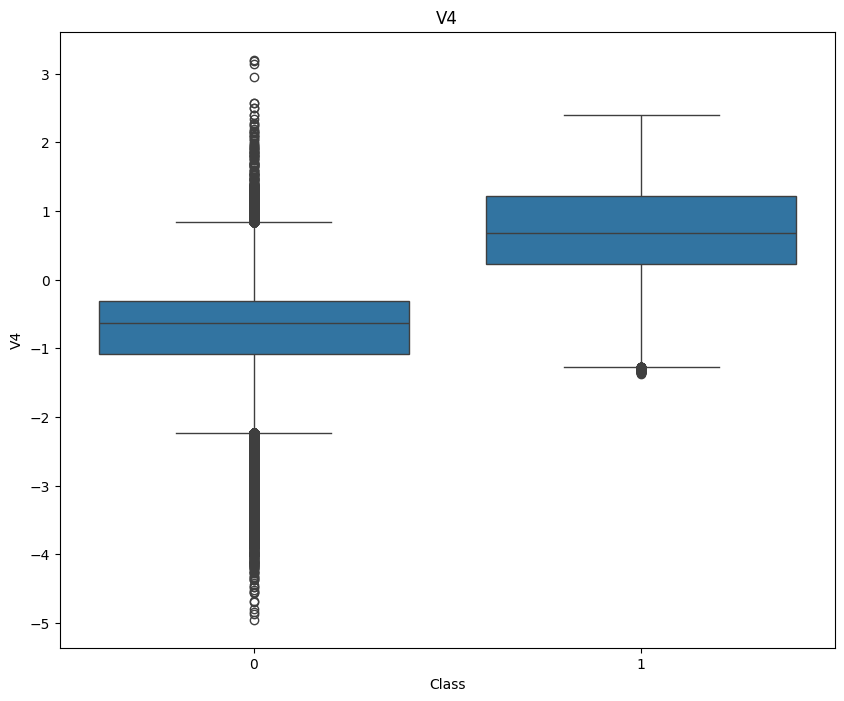

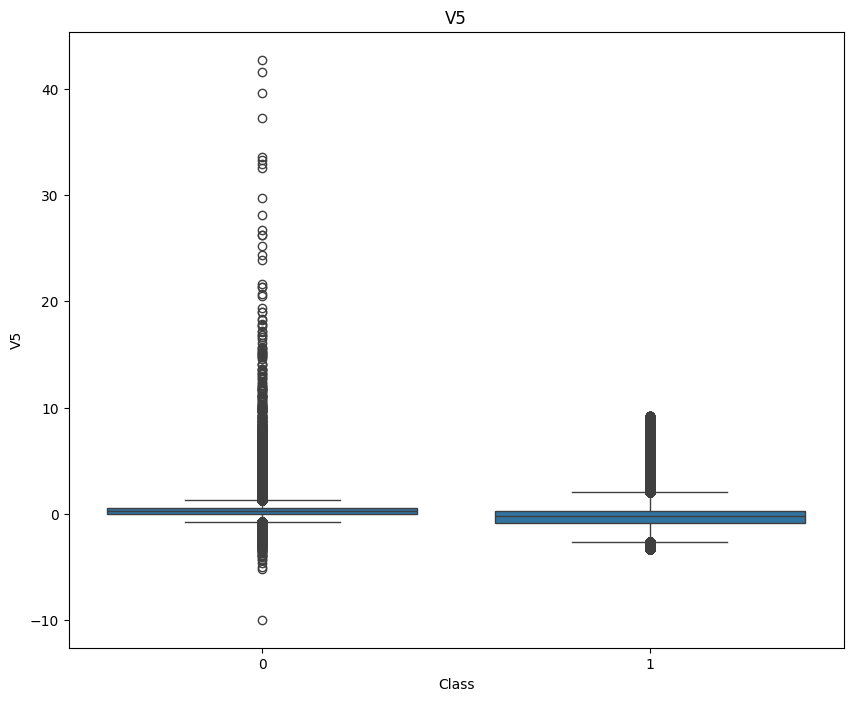

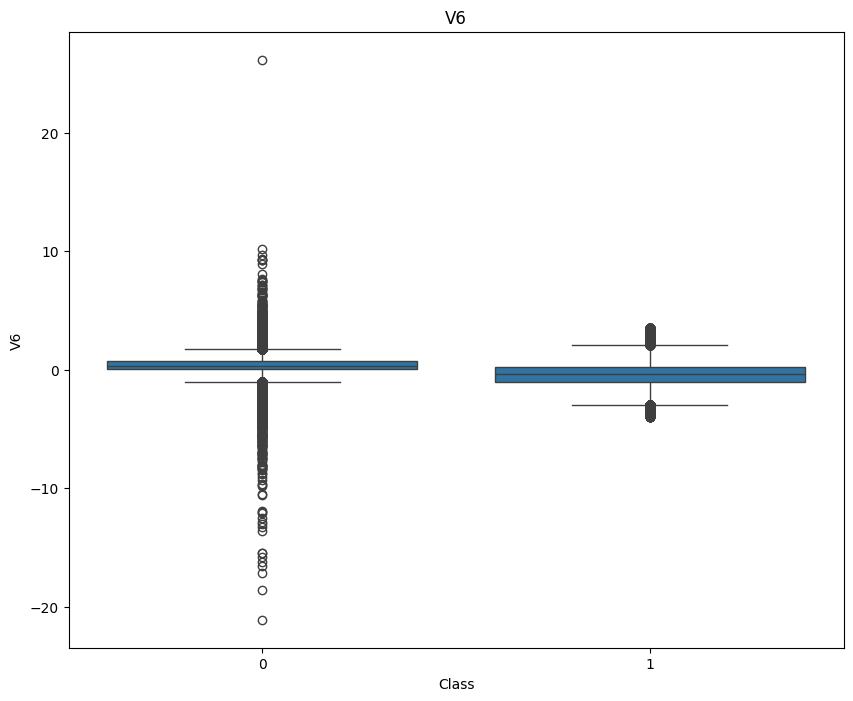

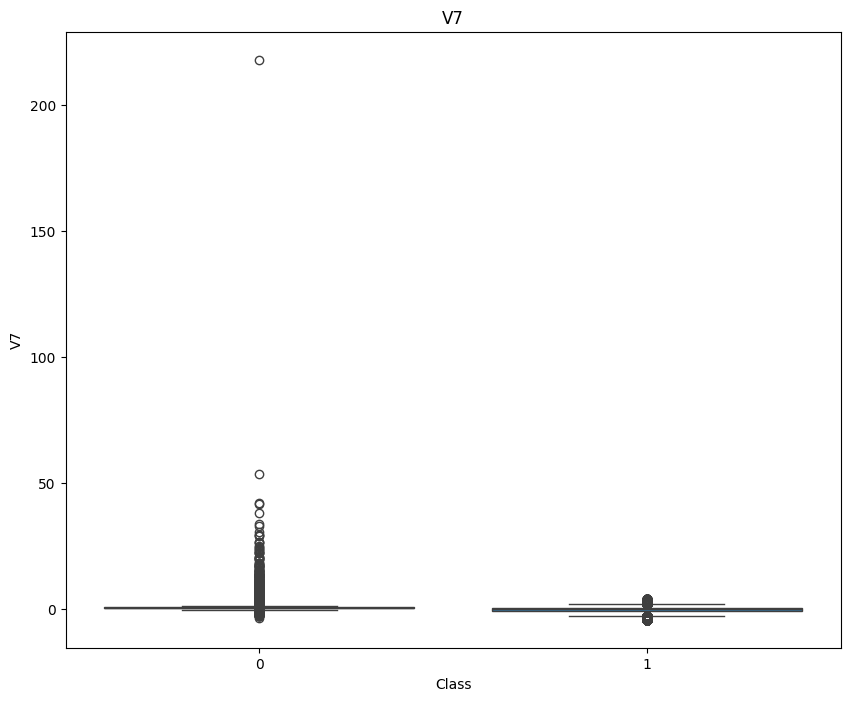

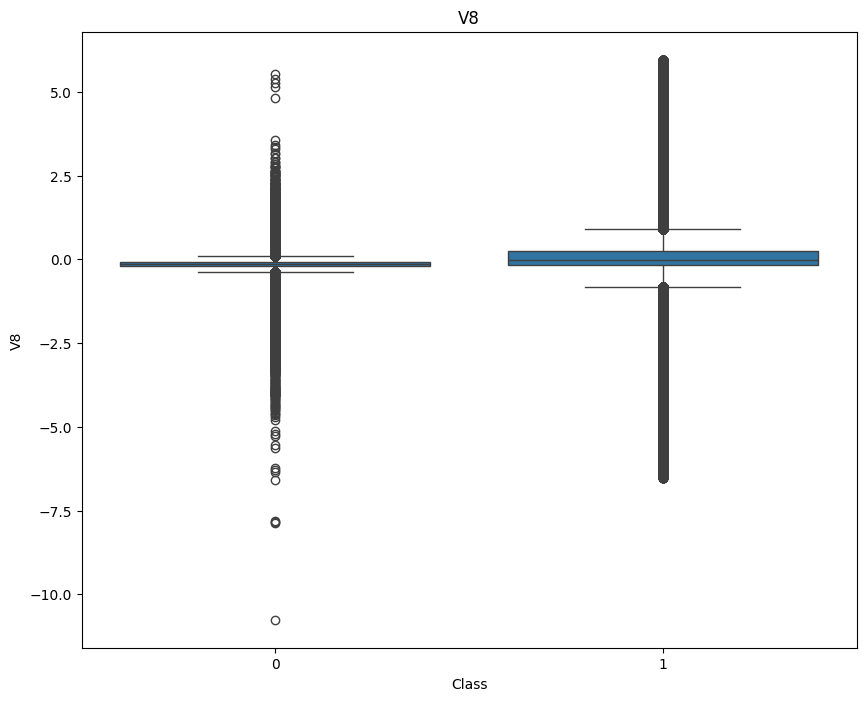

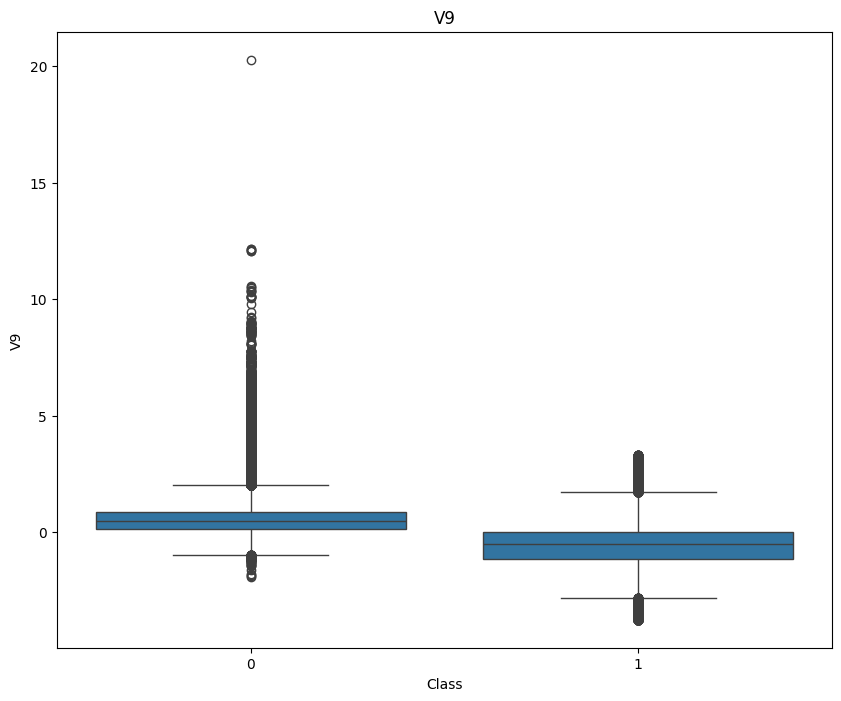

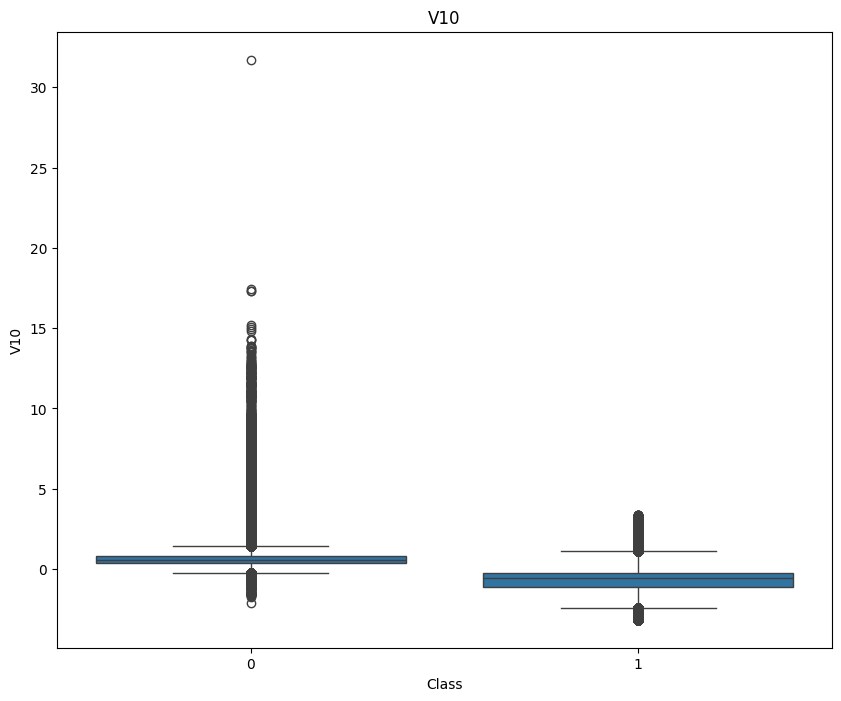

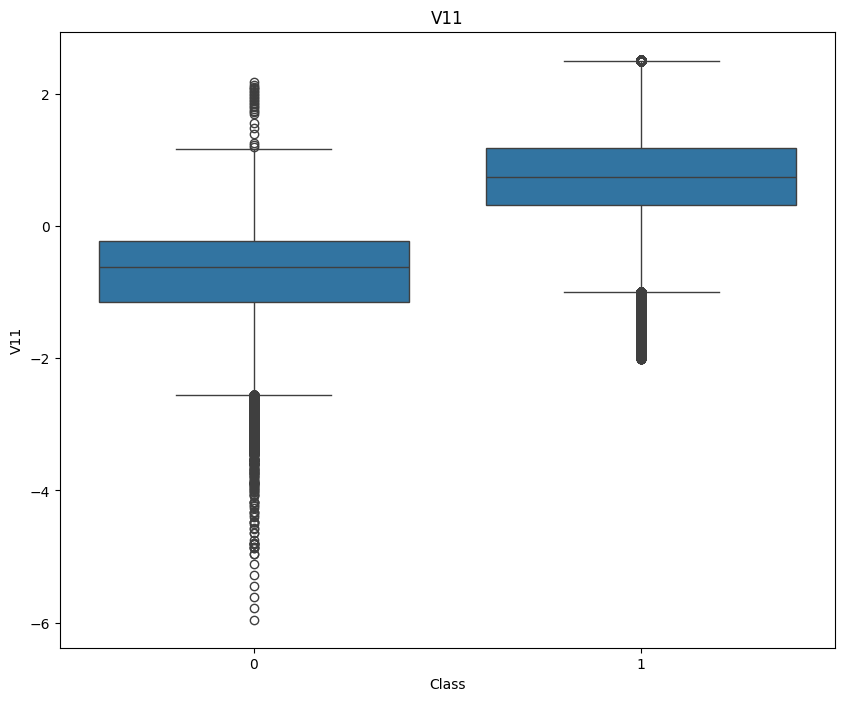

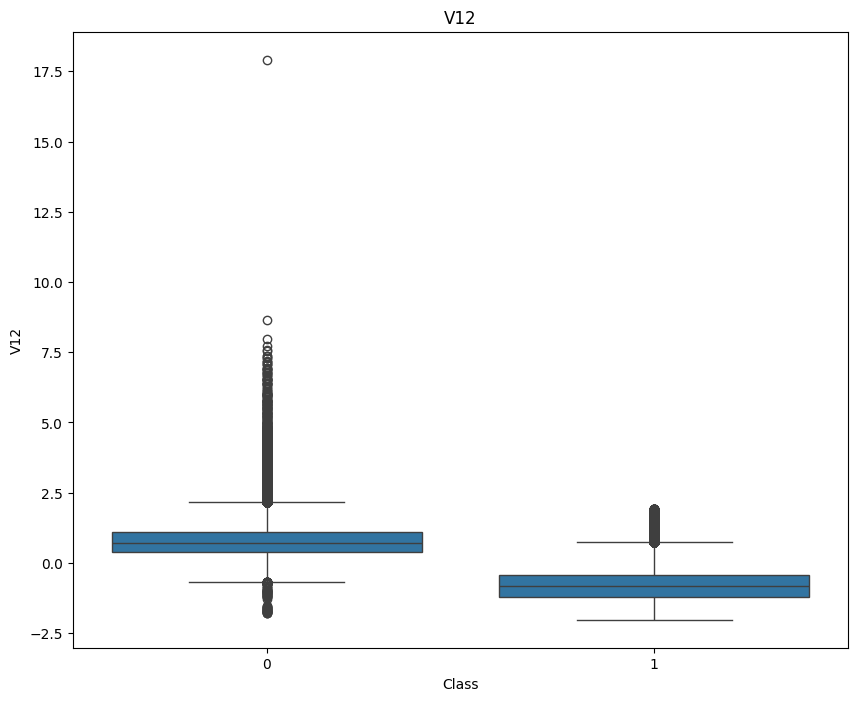

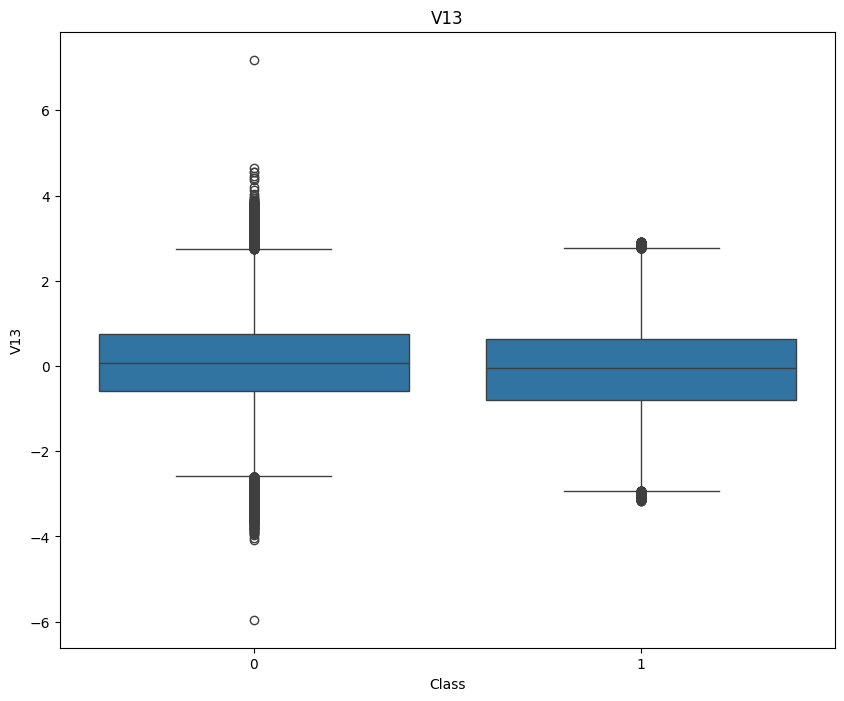

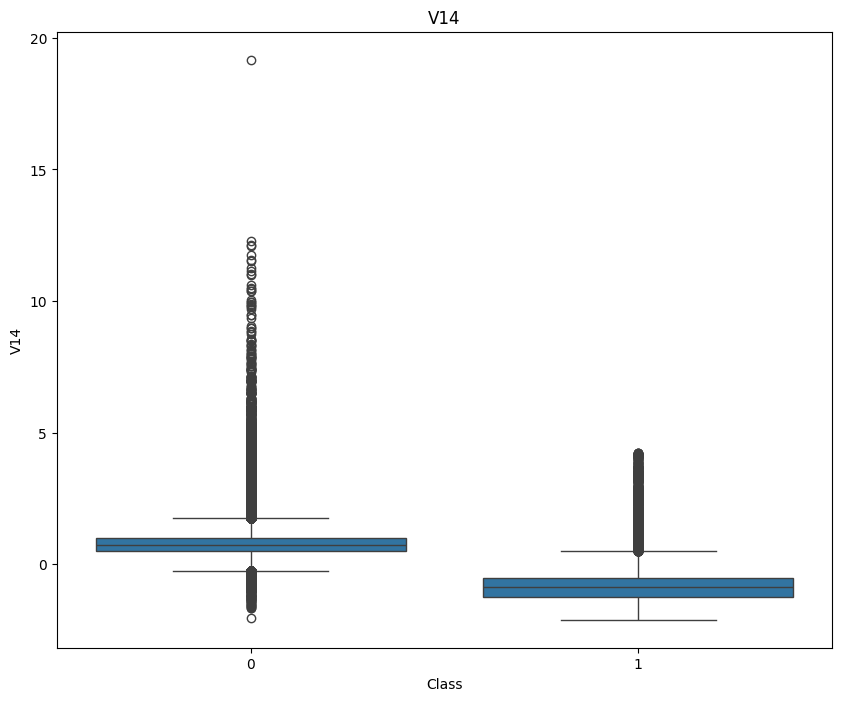

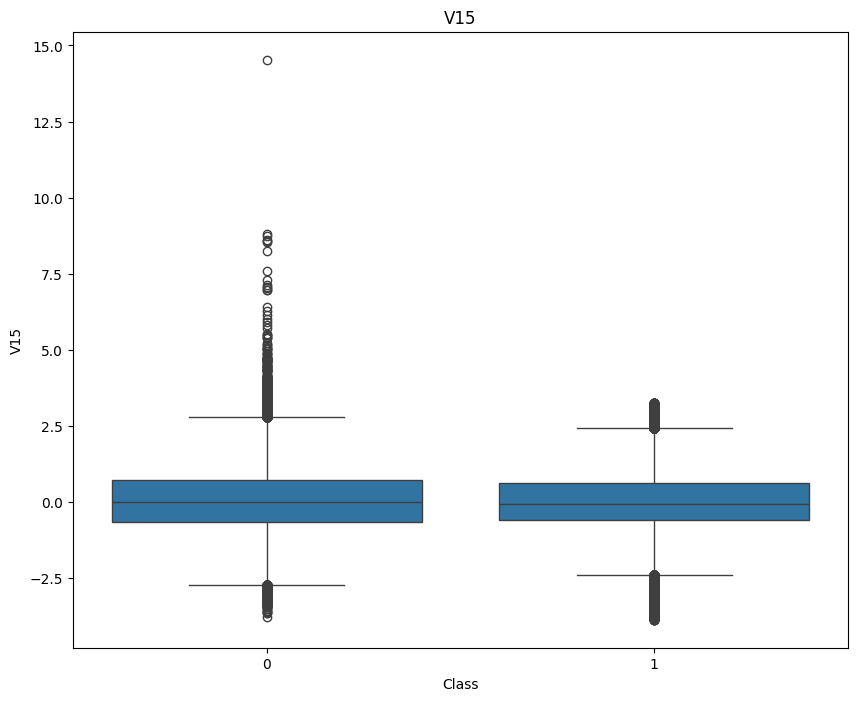

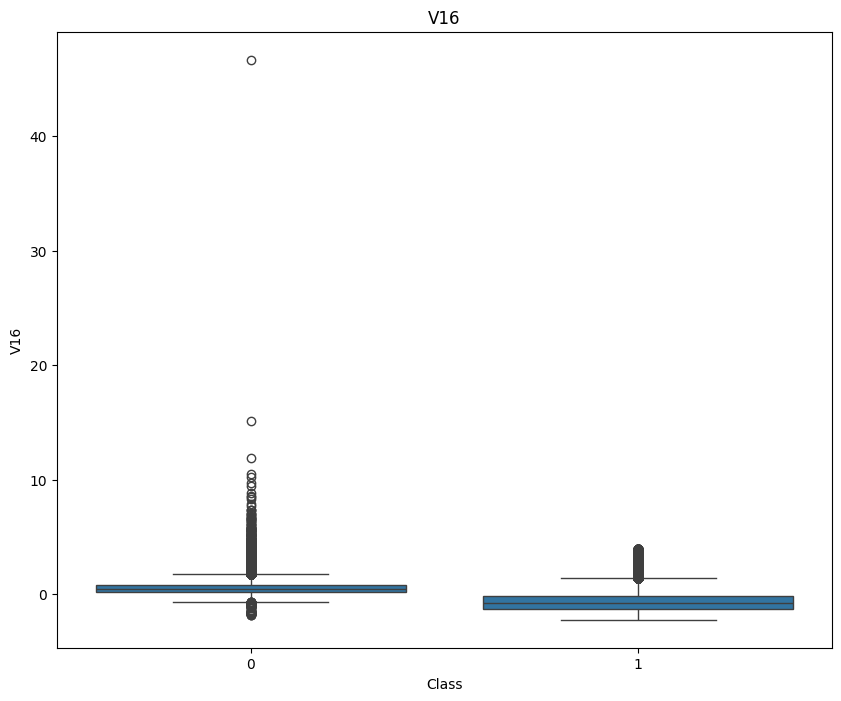

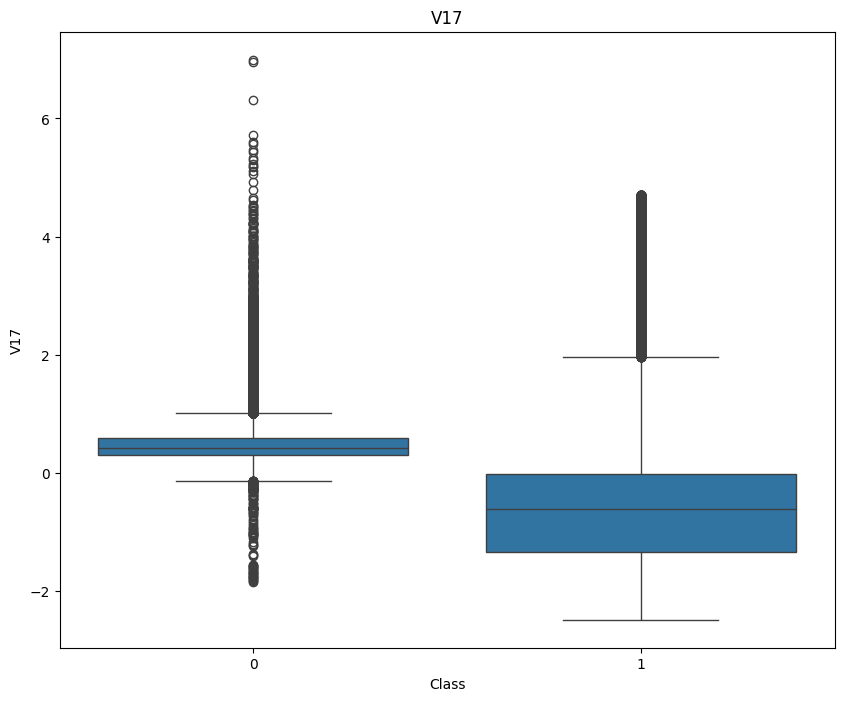

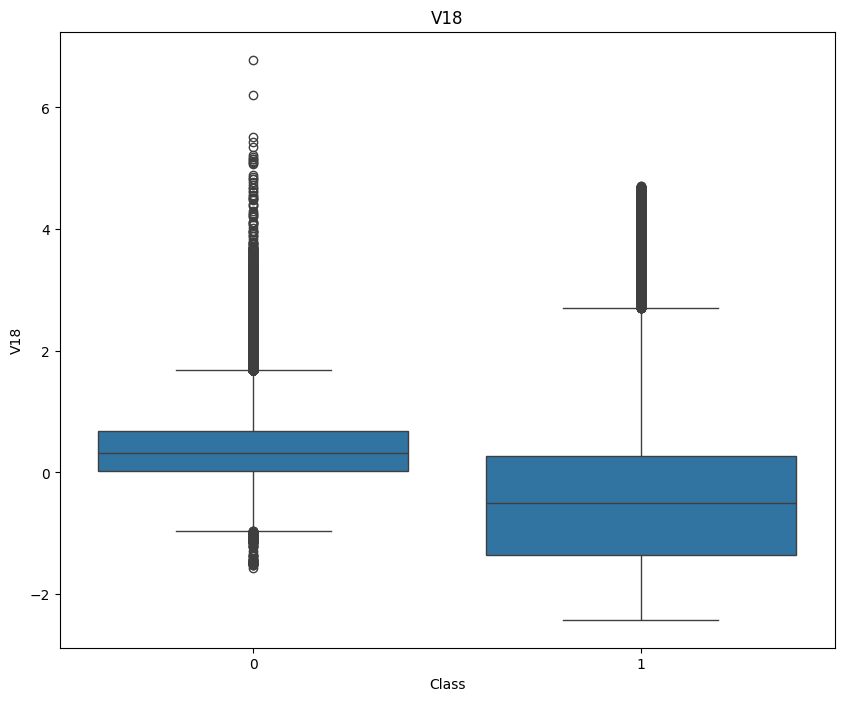

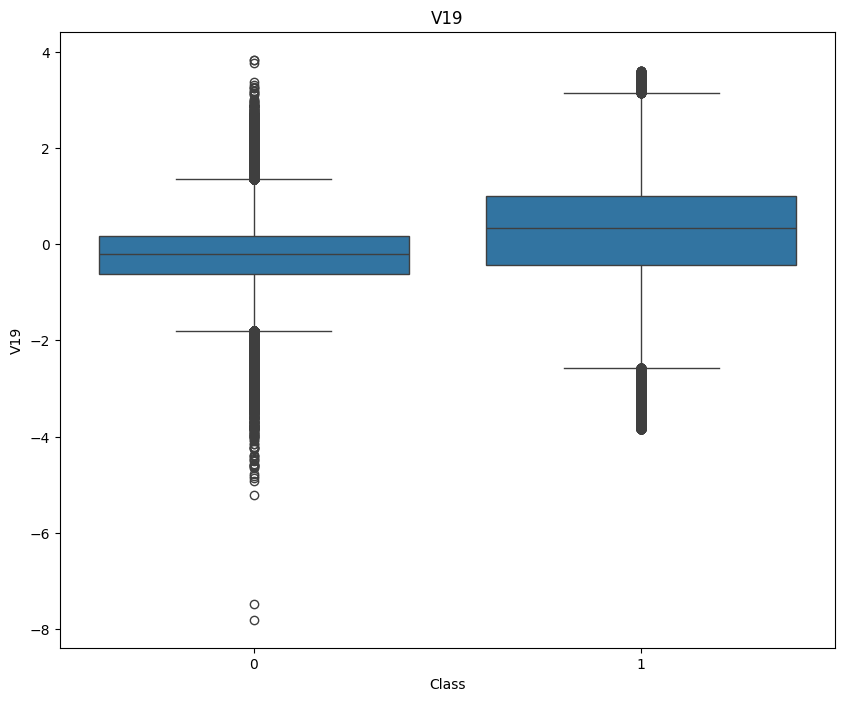

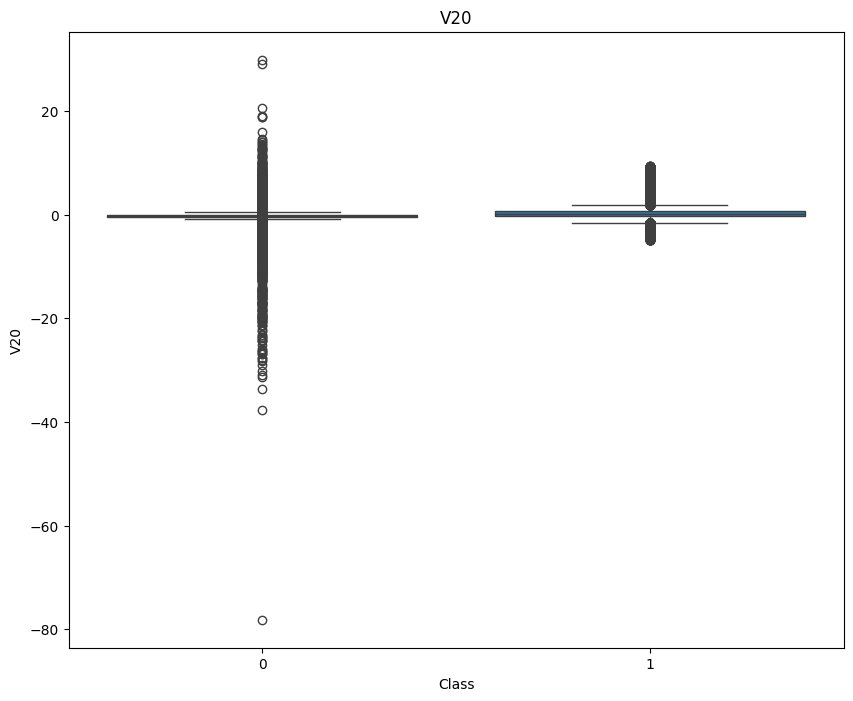

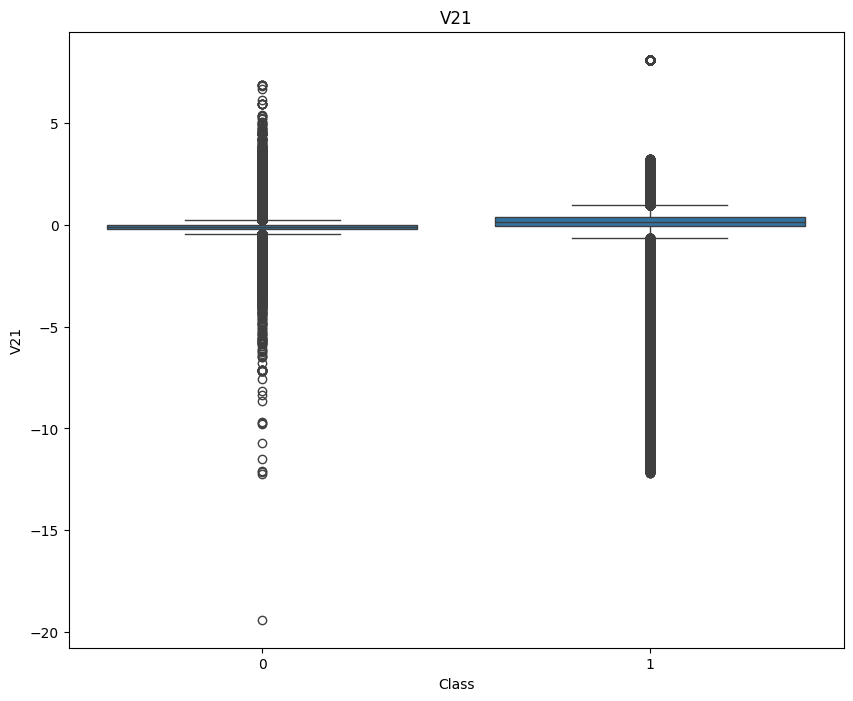

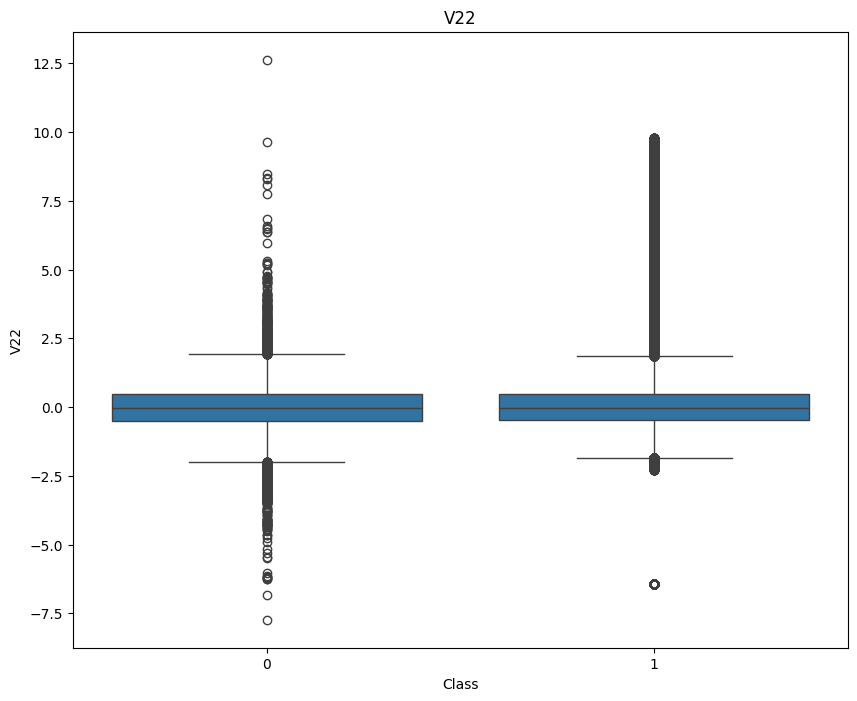

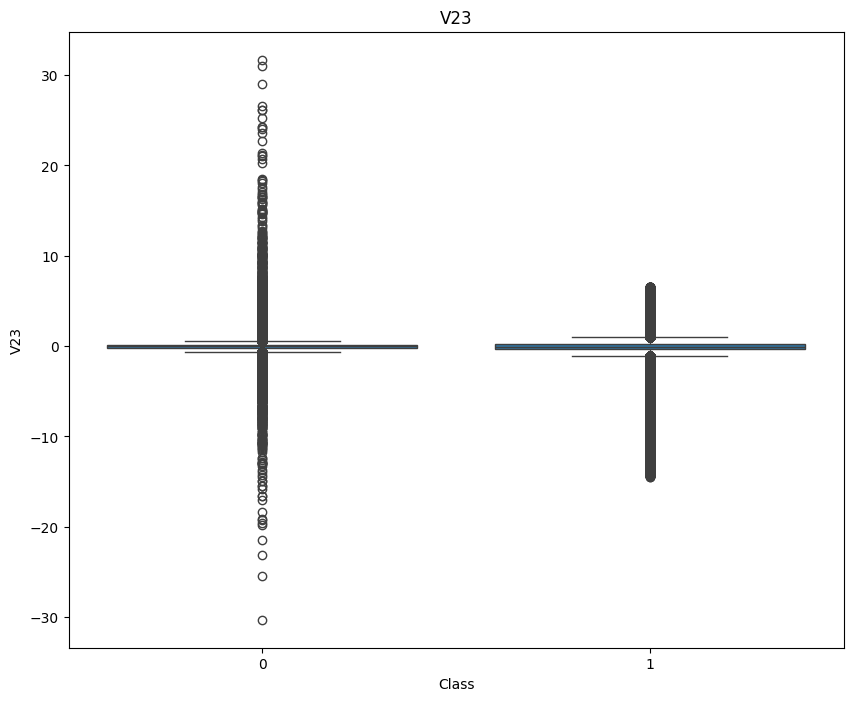

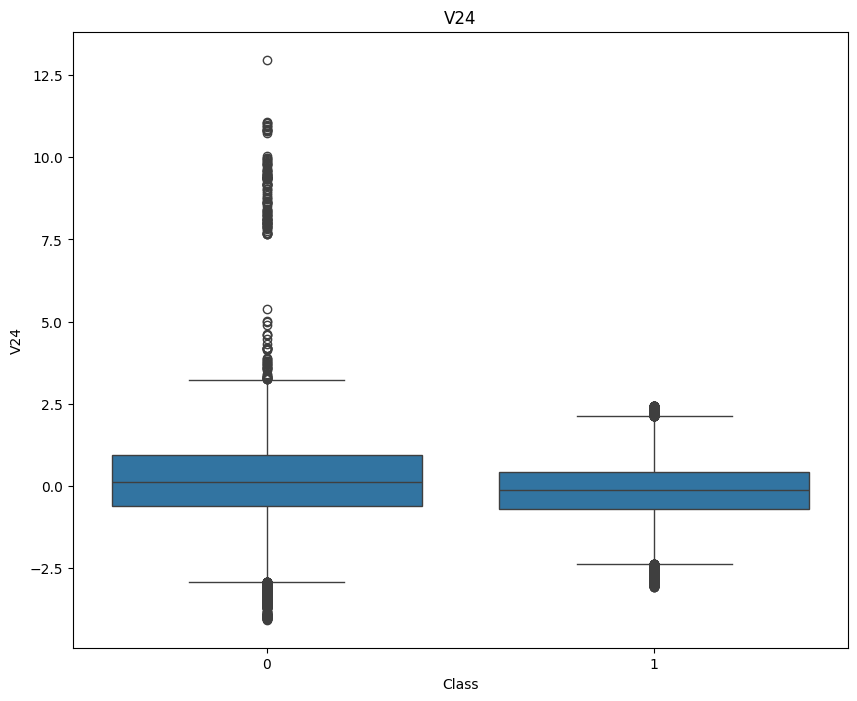

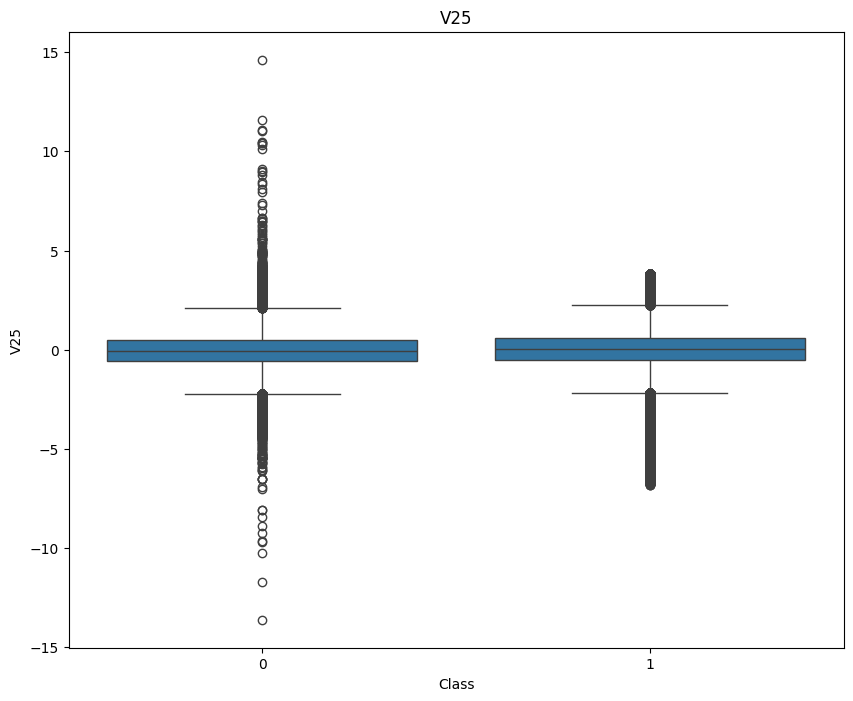

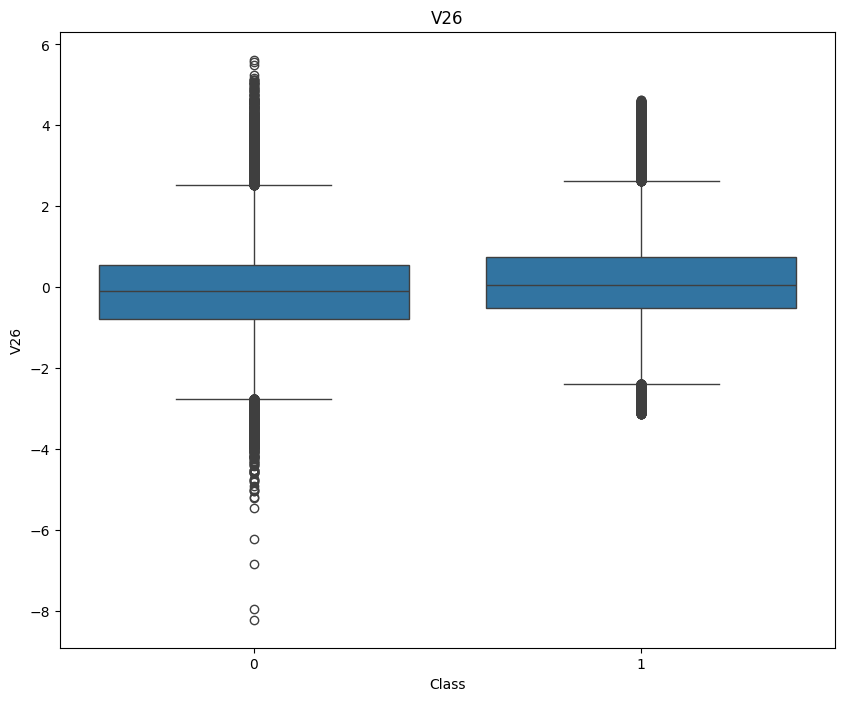

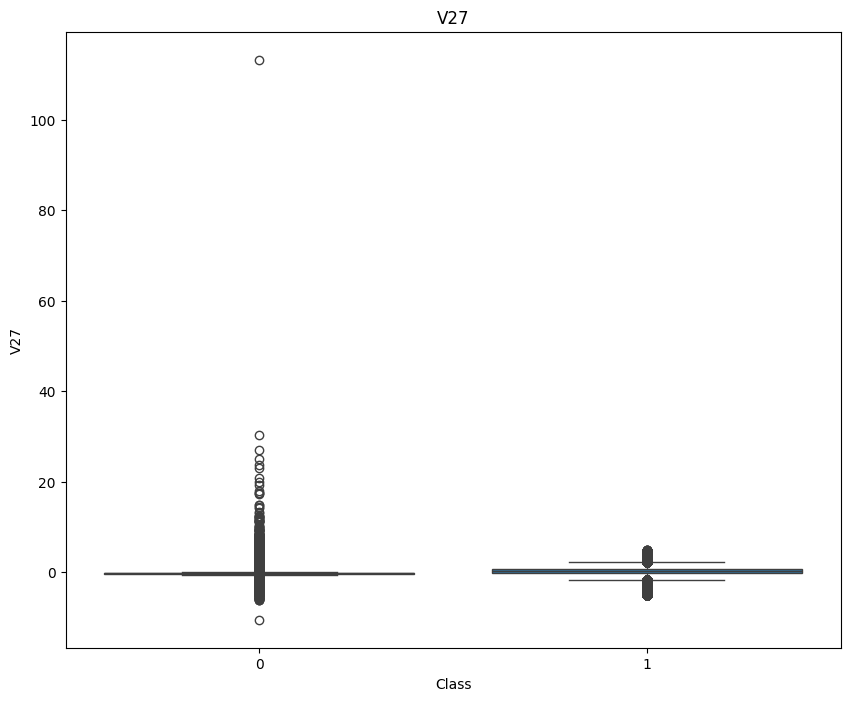

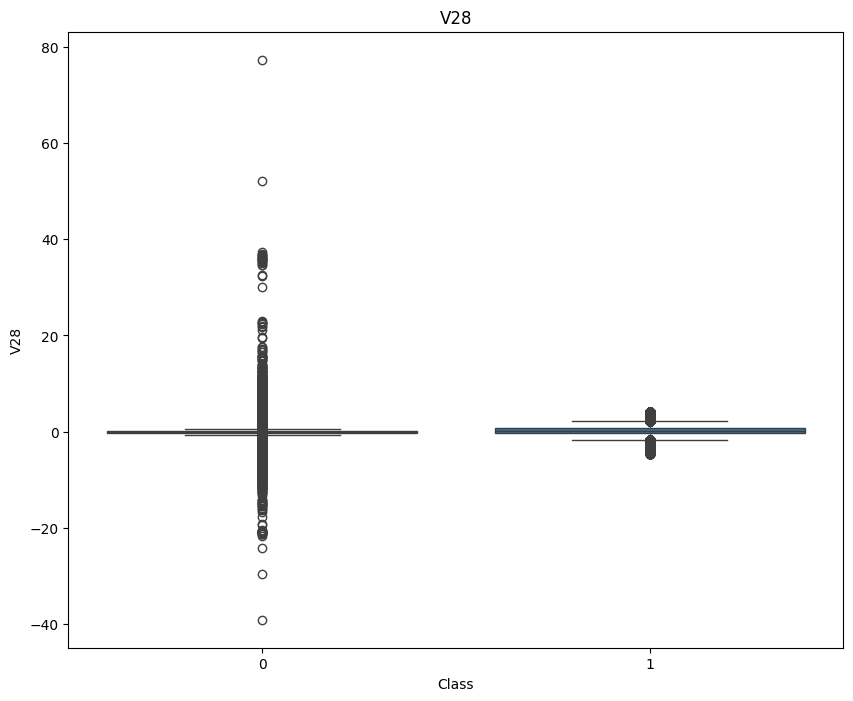

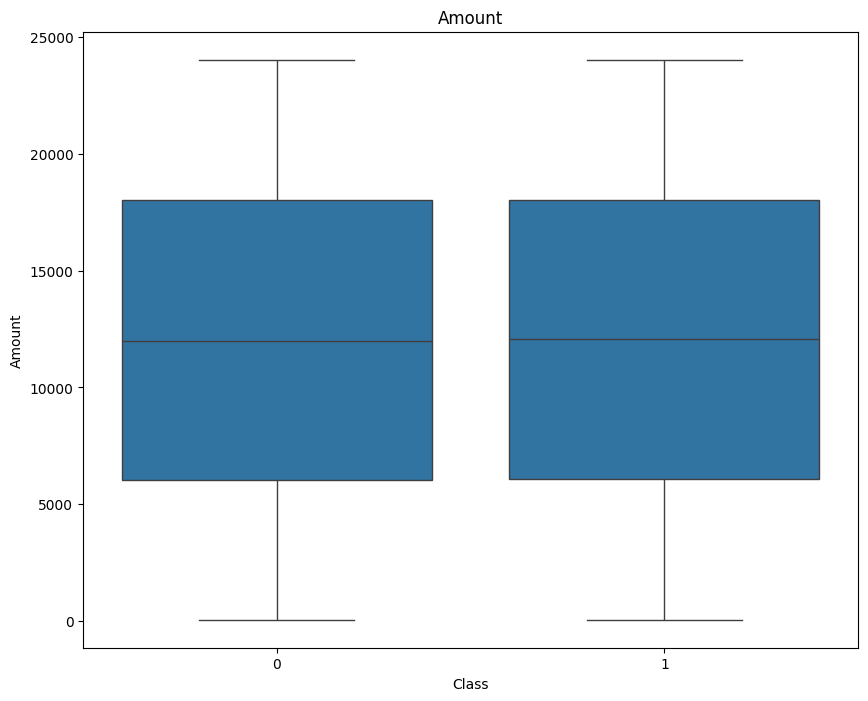

excluding boxplot for column: Class


In [ ]:
#checking for outliers
columns = data.columns
for col in columns:
  if col == "Class":
    #checking outliers for every column excluding Class which is the target variable
    print(f"excluding boxplot for column: {col}")
  else:
    plt.figure(figsize=(10,8))
    sns.boxplot(x=data["Class"],y=data[col])
    plt.title(col)
    plt.show()

In [ ]:
#since outliers are significantly important for a fraud detection model i'm going to use a robust scalar to improve it for V features only
#we use it to squeexe the data points in the v features closer to the iqr (the box in the plot) and we use this to make our model stronger and at the same time not lose it's value of outliers
from sklearn.preprocessing import RobustScaler
scale = RobustScaler()
columns = data.columns

for col in columns:
  if col == "Class":
    print("excluded from scaling")
  elif col == "Amount":
    print("excluded from scaling (2)")
  else:
    data[col] = scale.fit_transform(data[[col]])

excluded from scaling (2)
excluded from scaling


In [ ]:
#now the second method to make sure our model will be fully optmized we are going to use log transformation for the Amount feature
#log transformation is a method where each variable is replaced with it's logarithm
#the reason for this method as you can see in the box plot fraud and non fraud are identical in height median and everything which makes it a weak predictor
#another reason is that there are no outliers which means that the box covered everything
#by applying log transformation we can ensure that our data variable will look more natural and effective for the model
data["Amount_logtrans"] = np.log1p(data["Amount"])
#dropping the original as it is replaced with a new one (the logarithm of the original)
data.drop(columns=["Amount"],inplace=True)

In [ ]:
#verifying and making sure the changes are properly done

In [ ]:
data.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class',
       'Amount_logtrans'],
      dtype='object')

In [ ]:
data

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Amount_logtrans
0,-0.119468,-0.402001,1.953233,-0.007309,0.066273,0.693238,0.352875,-0.064627,0.562614,0.317210,...,-0.232559,0.256645,-0.190941,0.110964,0.121787,-0.324140,0.143479,-0.213753,0,9.797188
1,0.771660,-0.265168,0.436443,-0.261105,0.267381,0.370777,0.213839,-0.077619,0.225996,0.225945,...,-0.500940,-0.606087,0.353782,-0.438725,0.179578,0.236357,-0.117594,-0.078854,0,8.784525
2,-0.119199,-0.979834,1.352430,-0.281891,-0.009583,1.420813,0.630207,0.079097,-0.313671,0.362005,...,0.103080,0.765148,2.554339,-0.865601,-0.541016,-0.230692,-0.199296,-0.359781,0,7.829845
3,-0.041857,-0.449350,1.366753,-0.745706,0.229665,1.128156,0.351954,0.206191,-0.264381,0.264355,...,-0.348250,-0.011404,-0.392428,-1.411675,0.916673,-0.386316,0.011885,0.097204,0,8.591454
4,-0.080963,-0.035395,1.194753,-0.274779,0.034146,0.478808,0.525620,-0.409657,0.848749,0.596529,...,-0.221212,0.793252,-0.259256,0.219371,-0.367630,0.830037,0.307712,0.675087,0,9.566613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,-0.529205,0.238222,-0.704430,0.717513,-1.477688,0.426782,-0.745853,1.269922,-0.913717,-1.204556,...,0.651785,0.468434,3.426865,-0.677919,0.515191,0.004502,5.449089,0.148868,1,8.388259
568626,-0.412621,-0.080703,-0.053592,-0.142012,-0.292878,0.167890,-0.309209,-0.138628,0.346955,-0.400344,...,0.220421,0.435355,-0.240420,-0.637685,-0.131548,1.512351,-2.121698,2.678597,1,8.445568
568627,-0.156200,0.158750,0.107348,0.027783,-0.168267,0.044911,-0.375946,0.394592,-0.190225,-0.344261,...,0.566817,0.590809,-0.384933,-0.343713,0.496545,-0.570167,-0.492389,-0.397231,1,10.067893
568628,0.522560,-0.458998,-0.235743,-0.051883,0.068129,-0.395128,0.428916,-0.389046,0.710102,-0.289788,...,-0.072991,-0.176326,-0.294395,-0.421901,-0.082846,-1.090633,0.021349,-0.097153,1,9.226394


In [ ]:
data.describe()
#the max for amount should'nt exceed 25k and must be 10.1 and as you can see here it was successful

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Amount_logtrans
count,568630.000000,568630.000000,568630.000000,568630.000000,568630.000000,5.686300e+05,5.686300e+05,568630.000000,5.686300e+05,568630.000000,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,5.686300e+05,5.686300e+05,568630.0,568630.000000
mean,0.066983,0.163682,-0.000276,0.054116,-0.110590,-8.341738e-02,-2.882884e-01,0.478068,-8.202653e-02,-0.222073,...,1.190468e-01,2.863541e-02,1.517475e-01,-1.175850e-02,7.420245e-03,0.009114,2.706033e-01,2.171537e-02,0.5,9.100957
std,0.715337,1.204482,0.782573,0.733663,1.363825,1.059706e+00,1.235350e+00,4.174388,8.865203e-01,0.845623,...,3.180467e+00,1.047812e+00,2.542304e+00,7.394720e-01,9.056640e-01,0.766412,1.564987e+00,1.558924e+00,0.5,0.957873
min,-2.433534,-60.020118,-2.491800,-3.578409,-13.684439,-2.245496e+01,-5.664329e+00,-44.423044,-3.408176e+00,-2.897009,...,-6.152637e+01,-8.075969e+00,-7.686844e+01,-3.019904e+00,-1.232104e+01,-6.296127,-1.615960e+01,-6.083121e+01,0.0,3.932022
25%,-0.337386,-0.422512,-0.508400,-0.427181,-0.510866,-5.559091e-01,-6.385506e-01,-0.324488,-5.862298e-01,-0.721075,...,-4.103122e-01,-4.853044e-01,-4.523770e-01,-4.935833e-01,-4.944516e-01,-0.475177,-2.066557e-01,-3.397650e-01,0.0,8.708787
50%,0.000000,0.000000,0.000000,0.000000,0.000000,7.353093e-18,1.714374e-17,0.000000,-6.151471e-18,0.000000,...,-1.103444e-17,-1.817733e-18,-8.820366e-18,-1.282831e-18,7.855172e-19,0.000000,-2.171856e-17,-1.352149e-18,0.5,9.395254
75%,0.662614,0.577488,0.491600,0.572819,0.489134,4.440909e-01,3.614494e-01,0.675512,4.137702e-01,0.278925,...,5.896878e-01,5.146956e-01,5.476230e-01,5.064167e-01,5.055484e-01,0.524823,7.933443e-01,6.602350e-01,1.0,9.800199
max,1.661500,5.417467,11.054214,2.402962,58.147739,2.764736e+01,2.688610e+02,25.349220,1.788778e+01,26.603357,...,2.583971e+01,1.326512e+01,8.076212e+01,9.575959e+00,1.324958e+01,4.318863,1.774756e+02,1.204577e+02,1.0,10.087513


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 30 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   V1               568630 non-null  float64
 1   V2               568630 non-null  float64
 2   V3               568630 non-null  float64
 3   V4               568630 non-null  float64
 4   V5               568630 non-null  float64
 5   V6               568630 non-null  float64
 6   V7               568630 non-null  float64
 7   V8               568630 non-null  float64
 8   V9               568630 non-null  float64
 9   V10              568630 non-null  float64
 10  V11              568630 non-null  float64
 11  V12              568630 non-null  float64
 12  V13              568630 non-null  float64
 13  V14              568630 non-null  float64
 14  V15              568630 non-null  float64
 15  V16              568630 non-null  float64
 16  V17              568630 non-null  floa

In [ ]:
data.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [ ]:
#making sure no changes made to the target (Class)
data["Class"].value_counts()

,count
Class,
0,284315
1,284315


In [ ]:
data["Class"].sort_values()

,Class
10,0
9,0
8,0
7,0
6,0
...,...
568601,1
568600,1
568599,1
568598,1


PHASE 2: Data Visualiztion

In Machine Learning, visualization is crucial for decision making and viewing  the relationahip between the features and target variables. e.g: correlation , data distrubution and comparison....etc

In this phase, we will make sure to accomplish this goal.

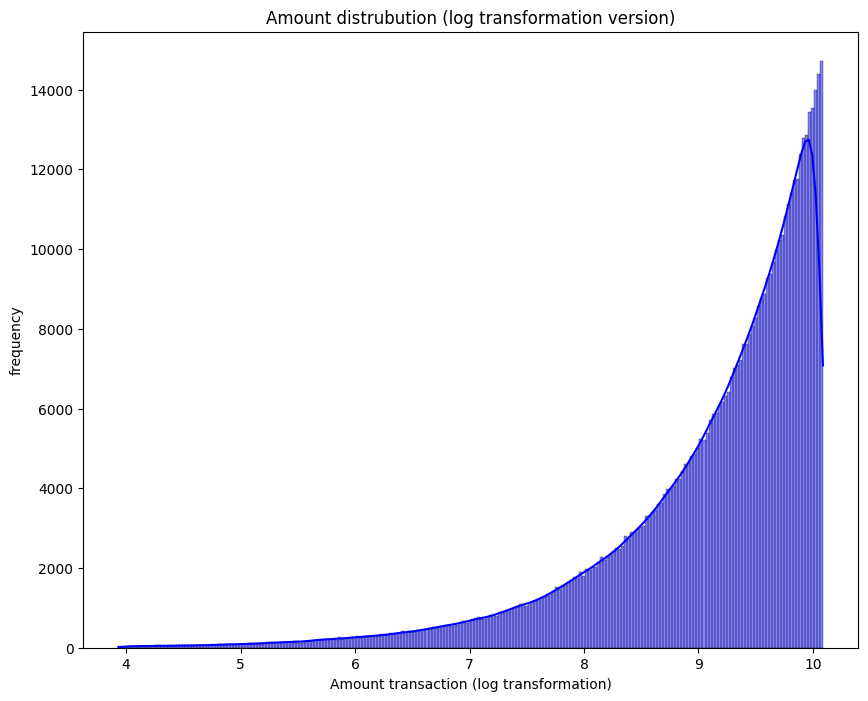

In [ ]:
#first, im goinng to use a histogram to plot the amount feature after log transformation
plt.figure(figsize=(10,8))
sns.histplot(data["Amount_logtrans"],kde=True,color="blue")
plt.title("Amount distrubution (log transformation version)")
plt.xlabel("Amount transaction (log transformation)")
plt.ylabel("frequency")

plt.show()

In [ ]:
#the feature is now evenly ditrubuted as you can see
#using a histogram was effective to visualize this new ditrubution
#by applying log transformation we can clearly see how it significantly improved.
#since the feature is evenly distrubuted, it will be easier and more effective for our logistic regression algorithm, it will be able to calculate far more faster and easier.


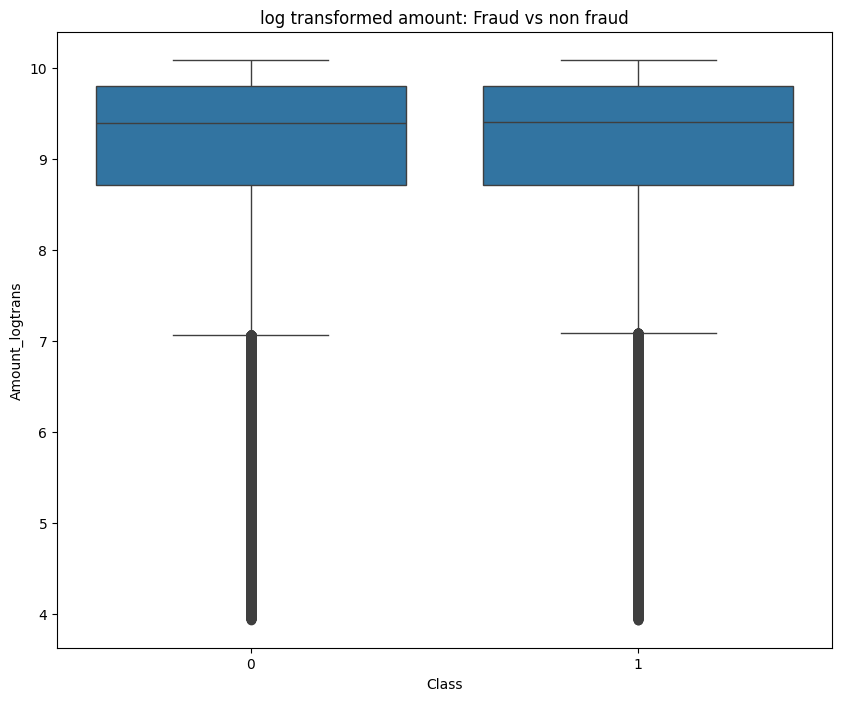

In [ ]:
#now i am going to use a box plot to compare class and the new amount feature after log transformation.
plt.figure(figsize=(10,8))
sns.boxplot(x=data["Class"],y=data["Amount_logtrans"])
plt.title("log transformed amount: Fraud vs non fraud")
plt.show()

In [ ]:
#there has been massive imporovments for the log transformed Amount feature
#it's easier now after squeezing the data from large numbers to only 4-10
#there a more anomalies this time that help us determine fraud
#However, the box hasn't changed much which sugguest this isn't our strongest feature.

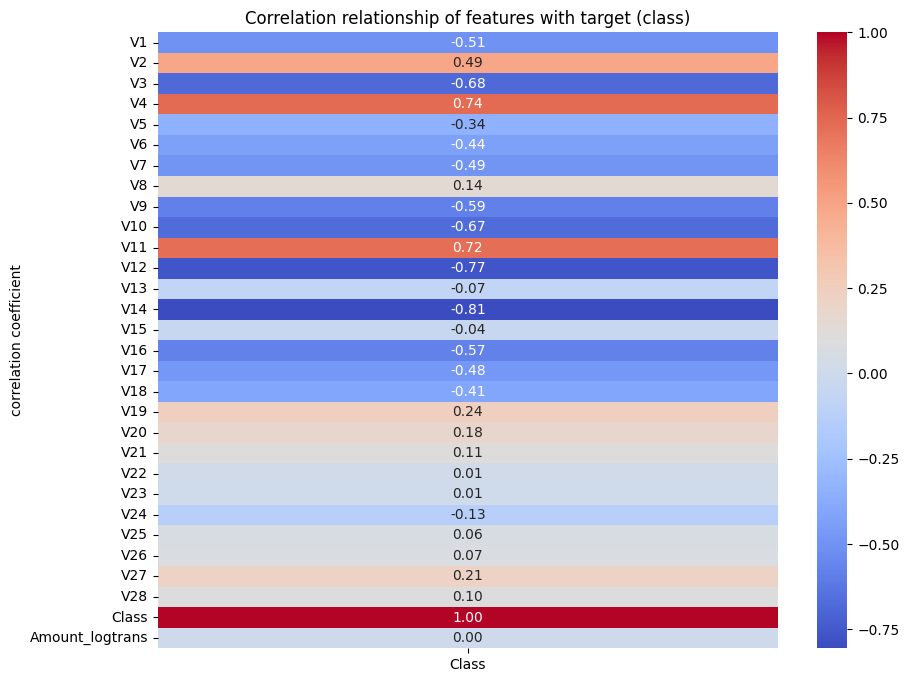

In [ ]:
#i am going to use a heatmap to visualize every single feature and how strong it's correlation is with out targer Class
plt.figure(figsize=(10,8))
sns.heatmap(data.corr()[["Class"]],cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation relationship of features with target (class)")
plt.ylabel("correlation coefficient")

plt.show()

In [ ]:
#the features with negative correlation to class shows an inverse relationship. Which means when they go down to negative, the likeliness of fraud increases and vice verca.
#the positive correlation features show a direct relationship. when they increase it means fraud increases and when it decreases fraud decreases.
#these features are crucial for our model
#the Amount feature shows 0.00 correlation, which we stated before when we viewed the box plot

In [ ]:
#the strongest features that would help to determine which transaction is fraud or not are: V4,V11 (positive) and V10 , V14 (negative)

In this phase i visualized the changes i made (amount log transformation) using a histogram to see how it was distrubuted and a box plot to compare with the original one and to see how it imporved.
Then , we used a correlation chart to view the features with the strongest correlation with the our target variable (Class).

And the next phase will be the final one which is building my model using logistic regression.


PHASE 3:Model Building

In this phase, i am going to split the data set into train and test.
After, i will implement the logistic regression algorithm to predict for fraud detection.
THe final step, is to evaluate the model with metric tests.

In [ ]:
#splitting the model into features and target variables
x = data.drop("Class",axis=1)
y = data["Class"]
#splitting the variables into train and test
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
#building a function for the algorithm to compare regularization parameters and decide which model is better
def Logreg(regular):
  model = LogisticRegression(C=regular)
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)


  print(classification_report(y_test, y_pred))

In [ ]:
Logreg(1.0)

              precision    recall  f1-score   support

           0       0.95      0.98      0.97     56863
           1       0.98      0.95      0.96     56863

    accuracy                           0.97    113726
   macro avg       0.97      0.97      0.97    113726
weighted avg       0.97      0.97      0.97    113726



In [ ]:
Logreg(0.1)

              precision    recall  f1-score   support

           0       0.95      0.98      0.97     56863
           1       0.98      0.95      0.96     56863

    accuracy                           0.96    113726
   macro avg       0.97      0.96      0.96    113726
weighted avg       0.97      0.96      0.96    113726



In [ ]:
Logreg(0.01)

              precision    recall  f1-score   support

           0       0.95      0.98      0.96     56863
           1       0.98      0.95      0.96     56863

    accuracy                           0.96    113726
   macro avg       0.96      0.96      0.96    113726
weighted avg       0.96      0.96      0.96    113726



In [ ]:
#reuslts of the parameter 1.0 is the most reliable due to it's high scores

In [ ]:
#in this step, i will finalise my model with the best parameter(1.0) and use cross validation technique to ensure it's performance
final_model = LogisticRegression(C=1.0,solver="liblinear")

cv_scores = cross_val_score(final_model,x,y,cv=5)
print(f"CV Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")


CV Accuracy Scores: [0.96248879 0.9648805  0.96164465 0.96097638 0.96314827]
Mean CV Accuracy: 0.9626
Standard Deviation: 0.0013


In [ ]:
#low std means model is stable and detects fraud and the high scores are consistent

In [ ]:
#our final model
logreg_model = LogisticRegression(C=1.0,solver="liblinear")
logreg_model.fit(x_train,y_train)

model_pred = logreg_model.predict(x_test)
acc = accuracy_score(y_test,model_pred)
prec = precision_score(y_test, model_pred)
rec = recall_score(y_test, model_pred)
f1 = f1_score(y_test,model_pred)

print(classification_report(y_test, model_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97     56863
           1       0.98      0.95      0.96     56863

    accuracy                           0.96    113726
   macro avg       0.97      0.96      0.96    113726
weighted avg       0.97      0.96      0.96    113726



<Axes: xlabel='Predicted', ylabel='Actual'>

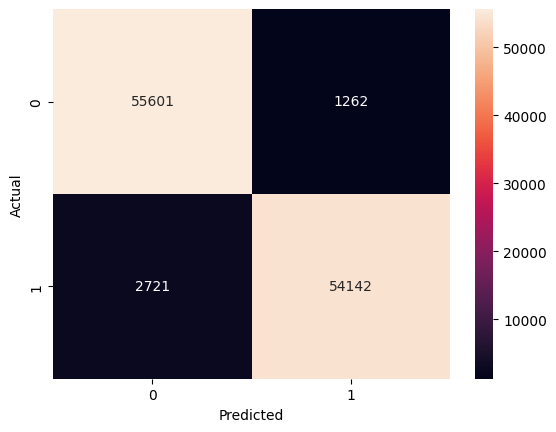

In [ ]:
#confusion matrix
confusion_matrix = pd.crosstab(y_test, model_pred, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(confusion_matrix,annot=True,fmt='d')

 finalized Logistic Regression model (C=1.0) was validated through 5-fold cross validation, confirming a highly consistent accuracy of 96.26%. This stability is further supported by the confusion matrix, which shows the model successfully identified 54142 fraudulent transactions with a high recall of 0.95, proving its effectiveness in differentiating fraud from legitimate activity.